# Night Image Segmentation — ENSEMBLE (4 models)
State-of-the-art pretrained ensemble model from University of Zagreb.
Ranked #2 on the ACDC benchmark with **83.82% mIoU**.

**Expected time:** ~8–10 min total setup, ~12 sec inference per image.

In [11]:
!nvidia-smi

Sat Apr 18 19:12:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
# Clone the repo
%cd /content
!git clone https://github.com/UNIZG-FER-D307/semseg-in-adverse-conditions.git
%cd semseg-in-adverse-conditions

# Install required packages
!pip install pytorch-lightning==2.0.6 einops==0.6.1 psutil==5.9.5 scipy opencv-python -q

# Install open_clip
!git clone https://github.com/mlfoundations/open_clip.git -q
!cd open_clip && pip install -e . -q

# Install timm
!git clone https://github.com/huggingface/pytorch-image-models.git -q
!cd pytorch-image-models && pip install -e . -q

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

print("\n✅ Setup complete!")

/content
Cloning into 'semseg-in-adverse-conditions'...
remote: Enumerating objects: 483, done.
remote: Counting objects: 100% (483/483), done.
remote: Compressing objects: 100% (372/372), done.
remote: Total 483 (delta 141), reused 433 (delta 94), pack-reused 0 (from 0)
Receiving objects: 100% (483/483), 24.72 MiB | 22.80 MiB/s, done.
Resolving deltas: 100% (141/141), done.
/content/semseg-in-adverse-conditions
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.8/722.8 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 52.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
  Building editable for open_clip_torch (pyproject.toml) .

In [13]:
# Copy 4 ensemble checkpoints from Drive
!mkdir -p ckpts/models_ensemble
!cp /content/drive/MyDrive/night_seg_ckpts/ensemble/*.ckpt ckpts/models_ensemble/

# Verify — should show 4 files, each ~2.3 GB
!ls -lh ckpts/models_ensemble/

total 9.2G
-rw------- 1 root root 2.3G Apr 18 19:13 sn-pyr_cn-lg_ud-320_ens1.ckpt
-rw------- 1 root root 2.3G Apr 18 19:14 sn-pyr_cn-lg_ud-320_ens2.ckpt
-rw------- 1 root root 2.3G Apr 18 19:14 sn-pyr_cn-lg_ud-320_ens3.ckpt
-rw------- 1 root root 2.3G Apr 18 19:15 sn-pyr_cn-lg_ud-320_ens4.ckpt


In [14]:
# Copy your 4 rectified night PNGs from Drive
!mkdir -p my_night_images
!cp /content/drive/MyDrive/night_images/*.png my_night_images/

# Verify
!ls -lh my_night_images/

total 4.2M
-rw------- 1 root root 1.1M Apr 18 19:16 rectified_back.png
-rw------- 1 root root 1.2M Apr 18 19:16 rectified_front.png
-rw------- 1 root root 772K Apr 18 19:16 rectified_left.png
-rw------- 1 root root 1.2M Apr 18 19:16 rectified_right.png


In [15]:
!python generate_predictions.py \
  -sv pyr \
  -bv large \
  --gpus 0 \
  --upsample_dims 320 \
  --ckpt_path ckpts/models_ensemble/sn-pyr_cn-lg_ud-320_ens1.ckpt \
              ckpts/models_ensemble/sn-pyr_cn-lg_ud-320_ens2.ckpt \
              ckpts/models_ensemble/sn-pyr_cn-lg_ud-320_ens3.ckpt \
              ckpts/models_ensemble/sn-pyr_cn-lg_ud-320_ens4.ckpt \
  --img_dir my_night_images

Downloading: "https://dl.fbaipublicfiles.com/convnext/convnext_large_22k_1k_384.pth" to /root/.cache/torch/hub/checkpoints/convnext_large_22k_1k_384.pth
100% 755M/755M [00:17<00:00, 45.7MB/s]
Selected GPUs: [0]
Loading ensemble of 4 models...
['my_night_images/rectified_back.png', 'my_night_images/rectified_front.png', 'my_night_images/rectified_left.png', 'my_night_images/rectified_right.png']
> Found 4  images...
> Loaded <data.datasets.inference_data.inference_dataset.InferenceDataset object at 0x79f1649a9ca0> images for predictions generation.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: logs/pseudolabeling_logs/lightning_logs
2026-04-18 19:18:54.872926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:177653993

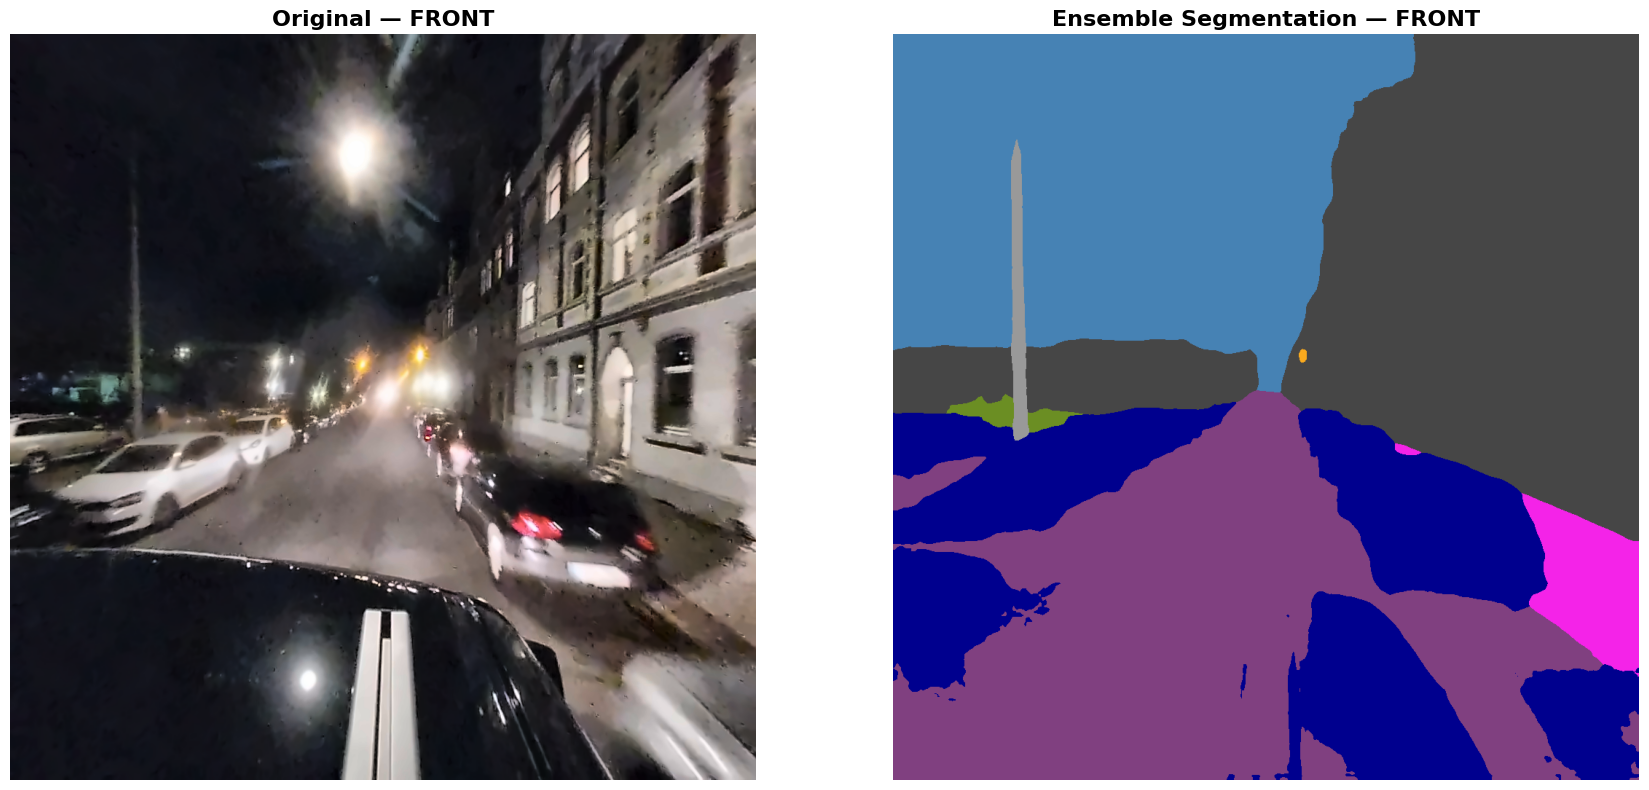

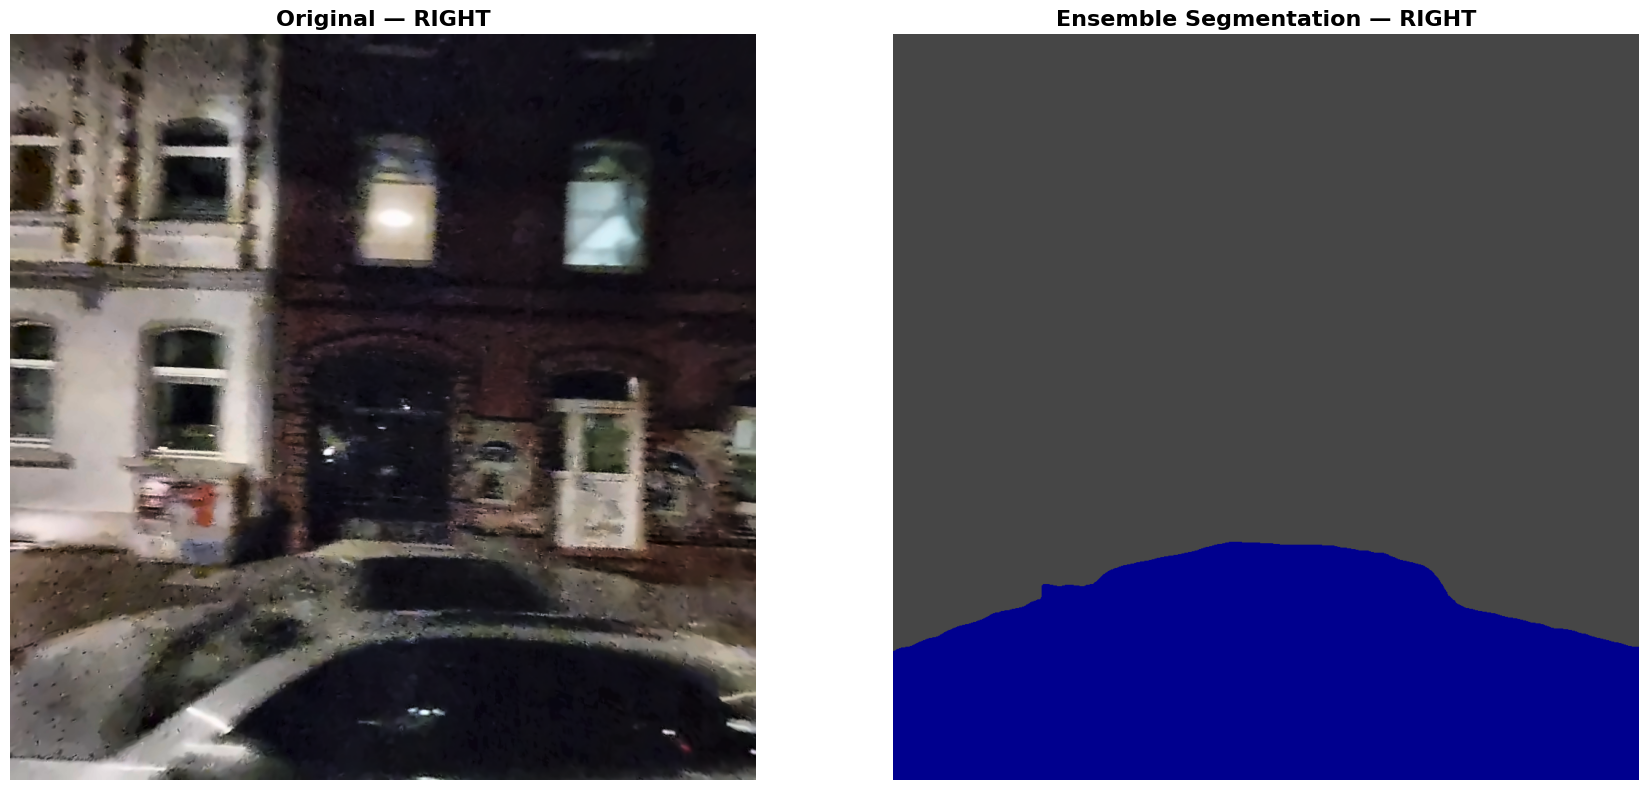

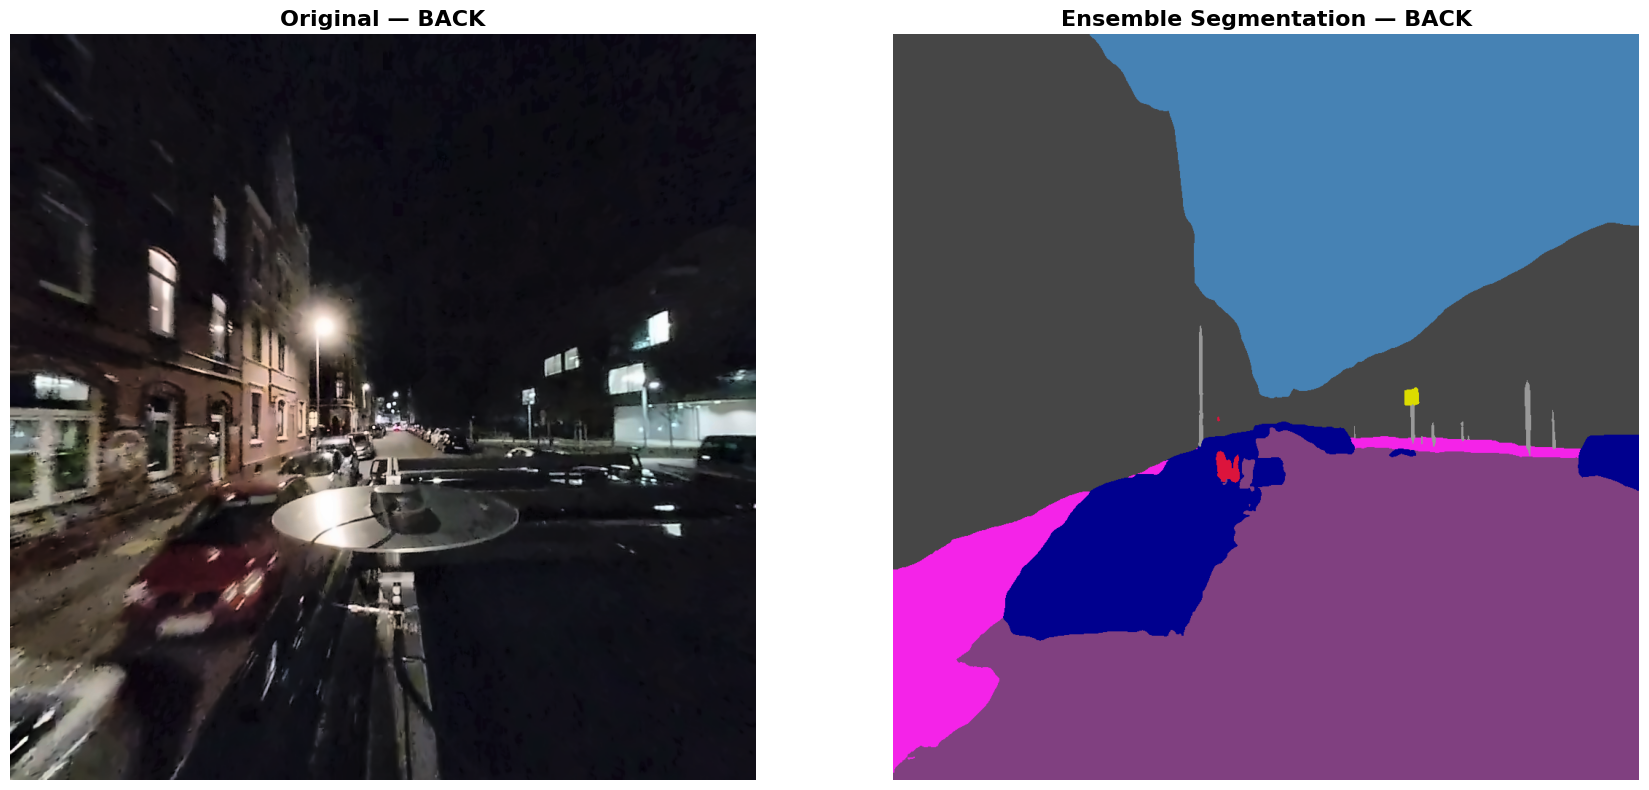

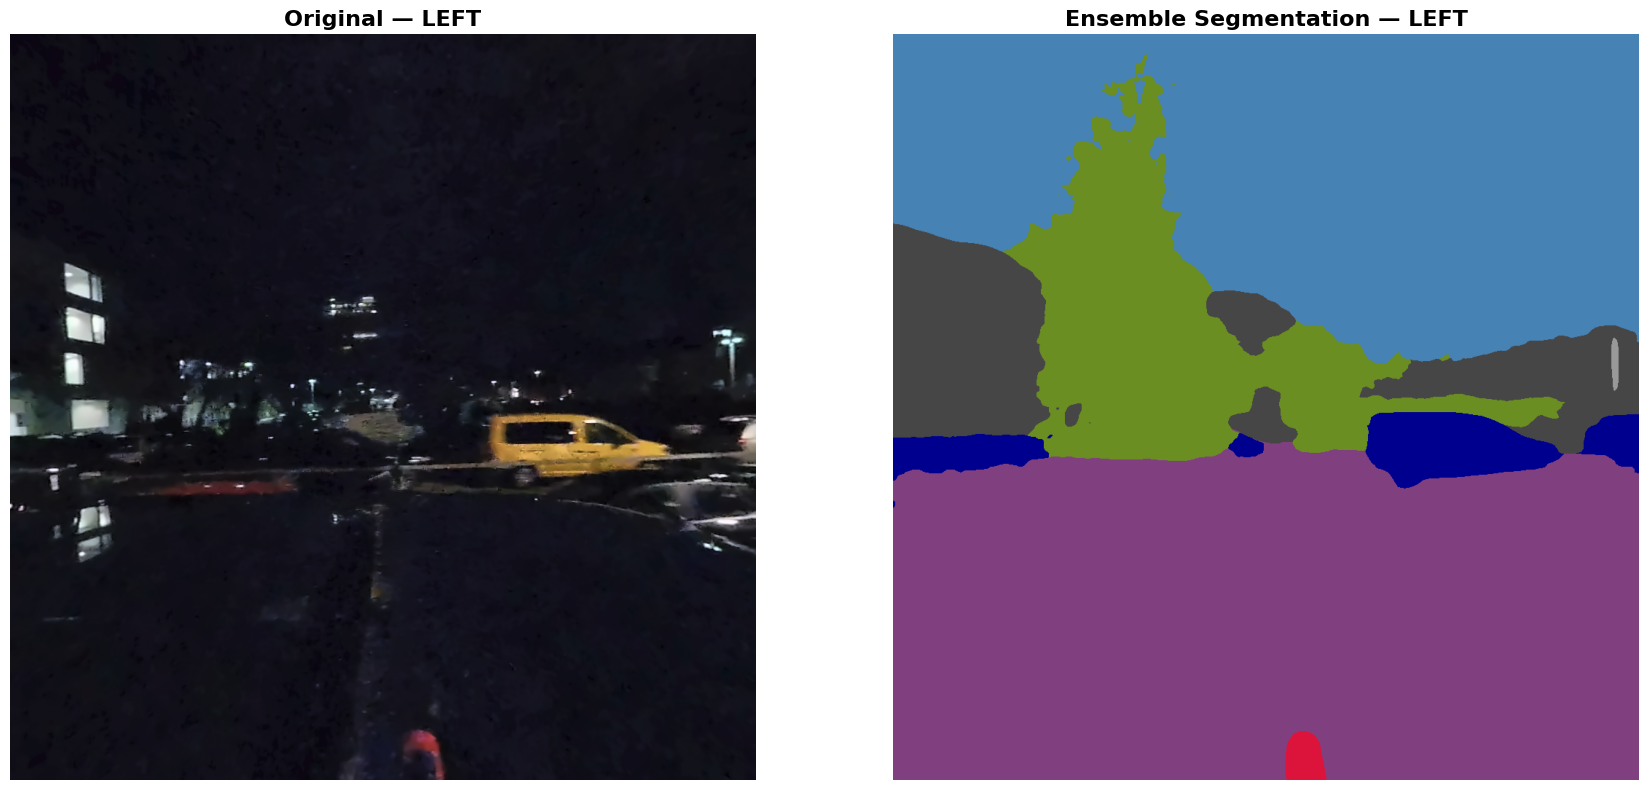

In [16]:
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import os

original_dir  = 'my_night_images'
colorized_dir = 'output_pred_test/colorized'

views = ['front', 'right', 'back', 'left']

for view in views:
    orig_path = os.path.join(original_dir, f'rectified_{view}.png')
    pred_path = os.path.join(colorized_dir, f'rectified_{view}_pseudolabel.png')

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    axes[0].imshow(PILImage.open(orig_path))
    axes[0].set_title(f'Original — {view.upper()}', fontsize=16, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(PILImage.open(pred_path))
    axes[1].set_title(f'Ensemble Segmentation — {view.upper()}', fontsize=16, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [17]:
# Save back to Drive so you don't lose them
RESULTS_DIR = "/content/drive/MyDrive/night_segmentation_results/ensemble"
!mkdir -p "{RESULTS_DIR}"
!cp -r output_pred_test/colorized           "{RESULTS_DIR}/"
!cp -r output_pred_test/pseudolabelTrainIds "{RESULTS_DIR}/"

print(f"✅ Saved to: {RESULTS_DIR}")

✅ Saved to: /content/drive/MyDrive/night_segmentation_results/ensemble
